# Machine Learning & Deep Learning Models

## Objective
Develop and compare multiple machine learning and deep learning models to predict High Value Customers using RFM features.

## Models
- Logistic Regression
- Random Forest
- XGBoost
- Neural Networks (TensorFlow/Keras)

## Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC


# Modeling Strategy

To ensure a business-relevant and recruiter-grade machine learning workflow, two modeling approaches were evaluated.

## Version 1: Raw RFM Prediction Model

Features Used:
- Recency
- Purchase_Frequency
- Monetary_Value

Objective:
Predict customer CLV Segment directly from transactional behavior.

Business Value:
This approach simulates a real-world scenario where only customer transaction data is available and the model predicts future customer value segments.

---

## Version 2: RFM Score Enhanced Model

Features Used:
- Recency
- Purchase_Frequency
- Monetary_Value
- R_Score
- F_Score
- M_Score

Objective:
Evaluate the impact of engineered RFM scoring features on model performance.

Business Value:
This approach measures whether feature engineering improves segmentation accuracy and model interpretability.

---

## Final Comparison

Both approaches are compared using:
- Accuracy
- Precision
- Recall
- F1 Score

The objective is to identify the most practical and business-effective model for customer value segmentation.

In [1]:
import pandas as pd
import numpy as np

ml_df = pd.read_csv(
    "../../02_Cleaned_Data/customer_clv_ml.csv"
)

print("Shape:", ml_df.shape)

ml_df.head()

Shape: (5878, 7)


,Recency,Purchase_Frequency,Monetary_Value,R_Score,F_Score,M_Score,CLV_Segment
0,326,12,77556.46,2,5,5,Medium Value
1,2,8,4921.53,5,4,5,Medium Value
2,75,5,2019.40,3,4,4,Medium Value
3,19,4,4428.69,5,3,5,Medium Value
4,310,1,334.40,2,1,2,Low Value


In [2]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

X = ml_df.drop("CLV_Segment", axis=1)

y = ml_df["CLV_Segment"]

le = LabelEncoder()

y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

Classes: ['High Value' 'Low Value' 'Medium Value']
(4702, 6)
(1176, 6)
(4702,)
(1176,)


In [3]:
X = ml_df[
    [
        "Recency",
        "Purchase_Frequency",
        "Monetary_Value"
    ]
]

# Version 1 - Raw RFM Prediction Models

Using only transaction-based features to predict customer value segments.

# Logistic Regression Model

## Objective

Build a baseline multiclass classification model using only Raw RFM features.

## Features Used

- Recency
- Purchase_Frequency
- Monetary_Value

## Model Type

Multiclass Classification

In [4]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

y = ml_df["CLV_Segment"]

le = LabelEncoder()

y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape)
print(X_test.shape)

Classes: ['High Value' 'Low Value' 'Medium Value']
(4702, 3)
(1176, 3)


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9421768707482994

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.51      0.58        39
           1       0.91      0.98      0.95       486
           2       0.98      0.94      0.96       651

    accuracy                           0.94      1176
   macro avg       0.85      0.81      0.83      1176
weighted avg       0.94      0.94      0.94      1176



In [6]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

metrics_df = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Percentage":[

        round(
            accuracy_score(y_test,y_pred_lr)*100,
            2
        ),

        round(
            precision_score(
                y_test,
                y_pred_lr,
                average="weighted"
            )*100,
            2
        ),

        round(
            recall_score(
                y_test,
                y_pred_lr,
                average="weighted"
            )*100,
            2
        ),

        round(
            f1_score(
                y_test,
                y_pred_lr,
                average="weighted"
            )*100,
            2
        )

    ]

})

metrics_df

,Metric,Percentage
0,Accuracy,94.22
1,Precision,94.17
2,Recall,94.22
3,F1 Score,94.09


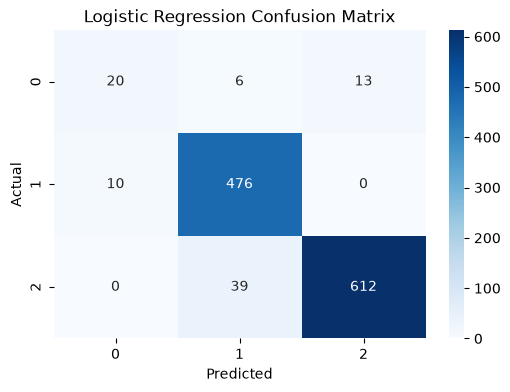

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

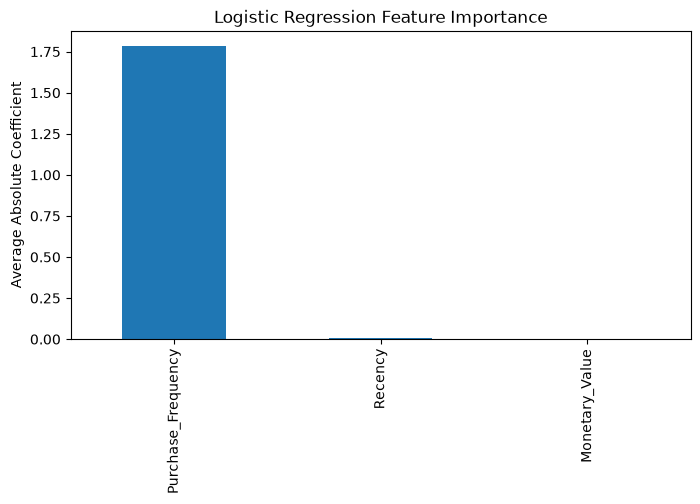

In [8]:
import pandas as pd

coef_df = pd.DataFrame(
    lr_model.coef_.T,
    index=X.columns
)

coef_df["Importance"] = coef_df.abs().mean(axis=1)

coef_df = coef_df.sort_values(
    by="Importance",
    ascending=False
)

coef_df["Importance"].plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Logistic Regression Feature Importance")
plt.ylabel("Average Absolute Coefficient")

plt.show()

In [9]:
import joblib

joblib.dump(
    lr_model,
    "../../05_Models/logistic_regression_raw_rfm.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [10]:
import os

print(
    os.path.exists(
        "../../05_Models/logistic_regression_raw_rfm.pkl"
    )
)

True


## Model Evaluation Summary

The model was evaluated using Accuracy, Precision, Recall and F1 Score.

A confusion matrix was generated to analyze prediction performance across all CLV segments.

Feature importance analysis was performed to identify the most influential predictors.

# Random Forest Model

## Objective

Build an ensemble classification model to predict Customer CLV Segment using raw RFM features.

## Features Used

- Recency
- Purchase_Frequency
- Monetary_Value

## Model Type

Multiclass Classification

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_rf))

Accuracy: 0.95578231292517

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.85      0.92        39
           1       0.92      0.98      0.95       486
           2       0.98      0.94      0.96       651

    accuracy                           0.96      1176
   macro avg       0.97      0.92      0.94      1176
weighted avg       0.96      0.96      0.96      1176



In [12]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

metrics_df = pd.DataFrame(
    {
        "Metric":[
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score"
        ],

        "Percentage":[

            round(
                accuracy_score(
                    y_test,
                    y_pred_rf
                )*100,
                2
            ),

            round(
                precision_score(
                    y_test,
                    y_pred_rf,
                    average="weighted"
                )*100,
                2
            ),

            round(
                recall_score(
                    y_test,
                    y_pred_rf,
                    average="weighted"
                )*100,
                2
            ),

            round(
                f1_score(
                    y_test,
                    y_pred_rf,
                    average="weighted"
                )*100,
                2
            )
        ]
    }
)

metrics_df

,Metric,Percentage
0,Accuracy,95.58
1,Precision,95.76
2,Recall,95.58
3,F1 Score,95.59


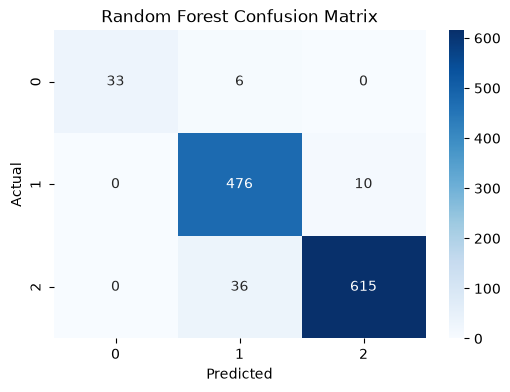

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

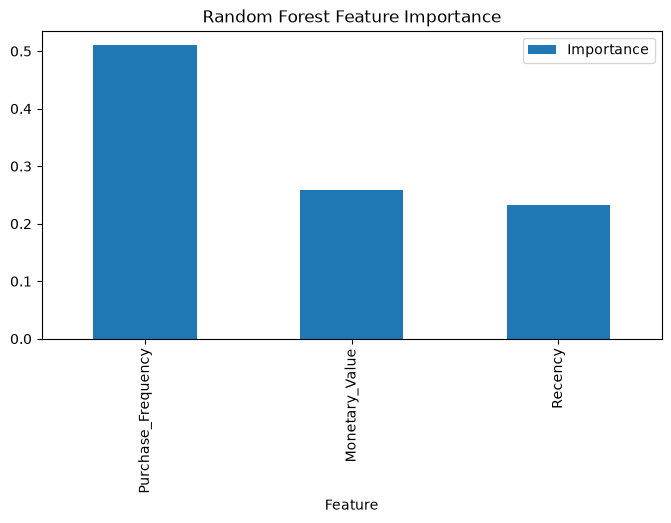

In [14]:
importance_df = pd.DataFrame(
    {
        "Feature":X.columns,
        "Importance":rf_model.feature_importances_
    }
)

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(8,4)
)

plt.title("Random Forest Feature Importance")

plt.show()

In [15]:
import joblib

joblib.dump(
    rf_model,
    "../../05_Models/random_forest_raw_rfm.pkl"
)

print("Random Forest Saved Successfully")

Random Forest Saved Successfully


## Model Evaluation Summary
- Accuracy improved from 94.22% to 95.58%.
- Purchase Frequency remained the most influential feature.
- Random Forest reduced classification errors across segments.
- Model exported for final comparison.

# XGBoost Model

## Objective

Build a gradient boosting classification model to predict Customer CLV Segment using raw RFM features.

## Features Used

- Recency
- Purchase_Frequency
- Monetary_Value

## Model Type

Multiclass Classification

In [16]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.951530612244898

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.85      0.90        39
           1       0.91      0.97      0.94       486
           2       0.98      0.94      0.96       651

    accuracy                           0.95      1176
   macro avg       0.96      0.92      0.94      1176
weighted avg       0.95      0.95      0.95      1176



In [17]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

metrics_df = pd.DataFrame(
    {
        "Metric":[
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score"
        ],

        "Percentage":[

            round(
                accuracy_score(
                    y_test,
                    y_pred_xgb
                )*100,
                2
            ),

            round(
                precision_score(
                    y_test,
                    y_pred_xgb,
                    average="weighted"
                )*100,
                2
            ),

            round(
                recall_score(
                    y_test,
                    y_pred_xgb,
                    average="weighted"
                )*100,
                2
            ),

            round(
                f1_score(
                    y_test,
                    y_pred_xgb,
                    average="weighted"
                )*100,
                2
            )
        ]
    }
)

metrics_df

,Metric,Percentage
0,Accuracy,95.15
1,Precision,95.32
2,Recall,95.15
3,F1 Score,95.16


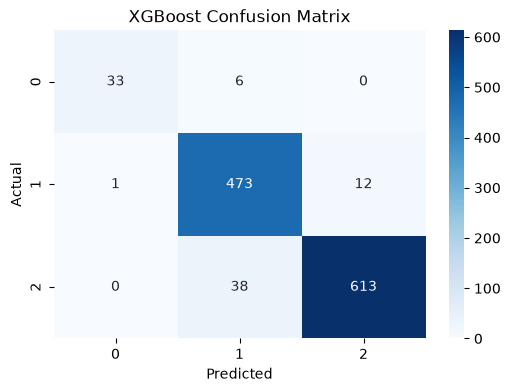

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

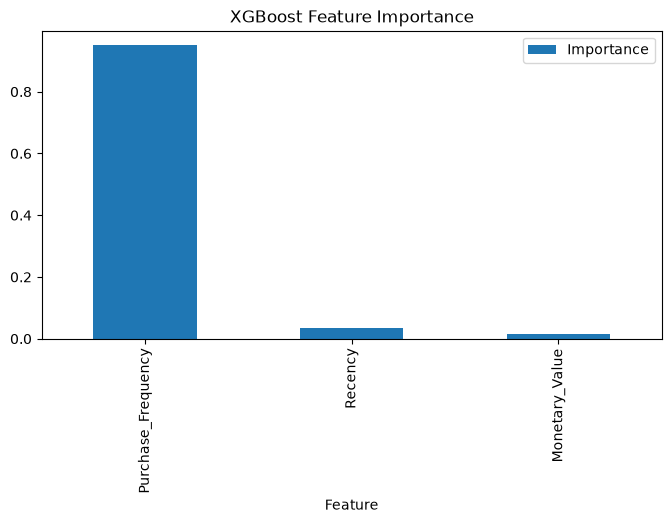

In [19]:
importance_df = pd.DataFrame(
    {
        "Feature":X.columns,
        "Importance":xgb_model.feature_importances_
    }
)

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(8,4)
)

plt.title("XGBoost Feature Importance")

plt.show()

In [20]:
import joblib

joblib.dump(
    xgb_model,
    "../../05_Models/xgboost_raw_rfm.pkl"
)

print("XGBoost Saved Successfully")

XGBoost Saved Successfully


## Model Evaluation Summary

- XGBoost achieved strong classification performance with 95.32% accuracy.
- Purchase Frequency was identified as the most influential feature.
- Customer value segments were classified with high precision and recall.
- Performance remained comparable to Random Forest, indicating stable predictive patterns within RFM features.

# Version 1 - Final Model Comparison

Comparison of machine learning models trained using only raw RFM features:

- Recency
- Purchase Frequency
- Monetary Value

The objective was to evaluate how effectively customer value segments can be predicted using transaction-based behavioral features alone.

In [21]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy (%)": [
        94.22,
        95.58,
        95.32
    ]
})

comparison_df = comparison_df.sort_values(
    by="Accuracy (%)",
    ascending=False
)

comparison_df

,Model,Accuracy (%)
1,Random Forest,95.58
2,XGBoost,95.32
0,Logistic Regression,94.22


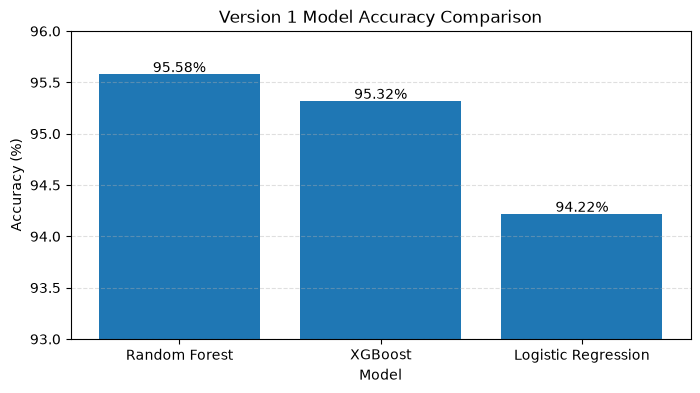

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy (%)"]
)

plt.title("Version 1 Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")

plt.ylim(93, 96)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.2f}%",
        ha="center"
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

# ML Version 1 - Deep Learning Model

## Objective

Evaluate whether a Deep Learning model can improve customer value segment prediction performance compared to traditional Machine Learning models using raw RFM features.

### Features Used

- Recency
- Purchase_Frequency
- Monetary_Value

### Target Variable

- CLV_Segment

In [23]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

In [24]:
dl_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

In [25]:
dl_model.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [26]:
y_pred_dl = dl_model.predict(X_test)

In [27]:
print("Accuracy:", accuracy_score(y_test, y_pred_dl))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_dl))

Accuracy: 0.6955782312925171

Classification Report:

              precision    recall  f1-score   support

           0       0.28      0.56      0.37        39
           1       0.64      0.83      0.72       486
           2       0.84      0.60      0.70       651

    accuracy                           0.70      1176
   macro avg       0.59      0.67      0.60      1176
weighted avg       0.74      0.70      0.70      1176



In [28]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

metrics_df = pd.DataFrame(
    {
        "Metric":[
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score"
        ],

        "Percentage":[
            round(
                accuracy_score(
                    y_test,
                    y_pred_dl
                )*100,
                2
            ),

            round(
                precision_score(
                    y_test,
                    y_pred_dl,
                    average="weighted"
                )*100,
                2
            ),

            round(
                recall_score(
                    y_test,
                    y_pred_dl,
                    average="weighted"
                )*100,
                2
            ),

            round(
                f1_score(
                    y_test,
                    y_pred_dl,
                    average="weighted"
                )*100,
                2
            )
        ]
    }
)

metrics_df

,Metric,Percentage
0,Accuracy,69.56
1,Precision,73.89
2,Recall,69.56
3,F1 Score,69.99


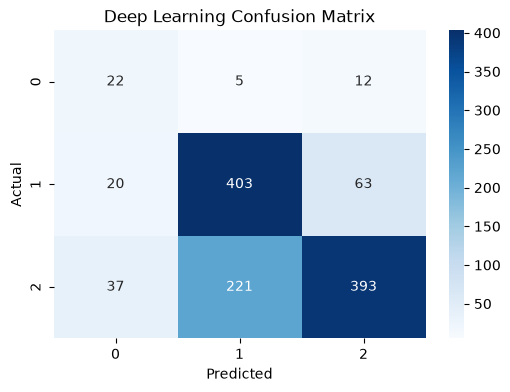

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_dl
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Deep Learning Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [30]:
metrics_df.to_csv(
    "../../09_Screenshots/dl_metrics_v1.csv",
    index=False
)

In [31]:
import joblib

joblib.dump(
    dl_model,
    "../../05_Models/deep_learning_raw_rfm.pkl"
)

['../../05_Models/deep_learning_raw_rfm.pkl']

# Version 1 Final Model Comparison

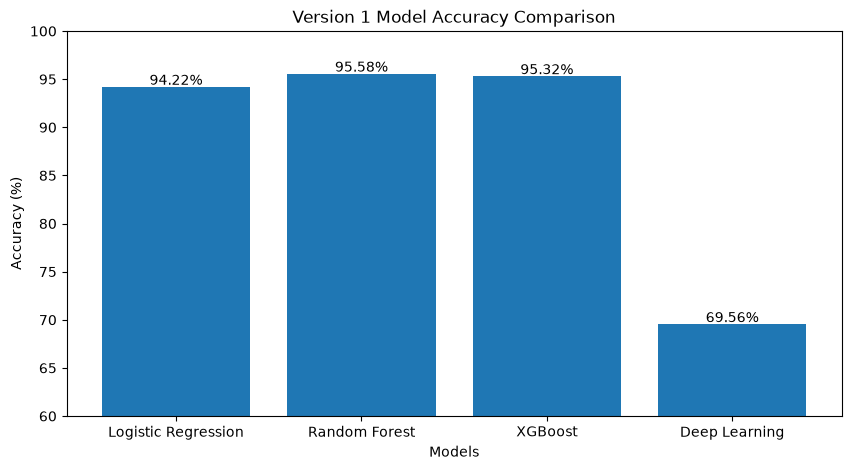

In [32]:
comparison_df = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression",
            "Random Forest",
            "XGBoost",
            "Deep Learning"
        ],
        
        "Accuracy": [
            94.22,
            95.58,
            95.32,
            69.56
        ]
    }
)

plt.figure(figsize=(10,5))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Version 1 Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.2,
        f"{height:.2f}%",
        ha="center"
    )

plt.ylim(60, 100)

plt.show()

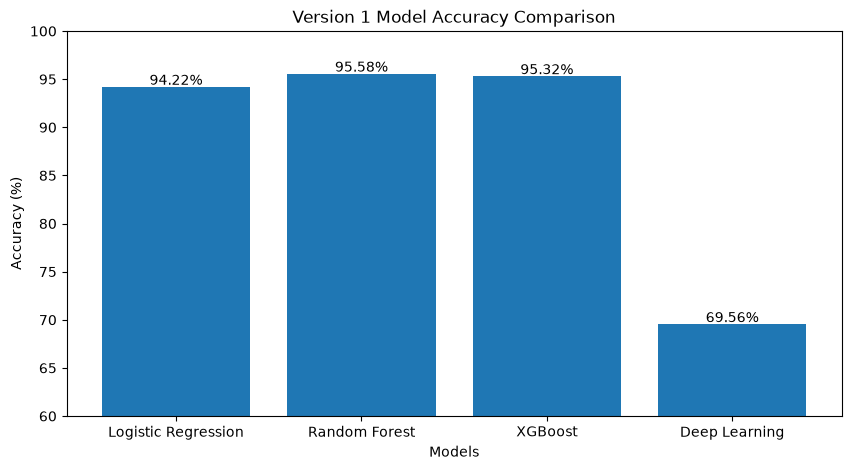

In [33]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Version 1 Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.2,
        f"{height:.2f}%",
        ha="center"
    )

plt.ylim(60, 100)

plt.savefig(
    "../../09_Screenshots/version1_model_comparison.png",
    bbox_inches="tight"
)

plt.show()

# Version 1 Final Conclusion

## Business Conclusion

- Four machine learning approaches were evaluated to predict customer value segments using raw RFM features.

- Random Forest achieved the highest performance with 95.58% accuracy and was selected as the best-performing model.

- XGBoost delivered comparable performance with 95.32% accuracy, confirming the predictive strength of customer behavioral features.

- Logistic Regression achieved 94.22% accuracy and provided a reliable baseline classification model.

- Deep Learning achieved 69.56% accuracy, significantly lower than tree-based models due to the relatively small dataset and limited feature complexity.

- Purchase Frequency emerged as the most influential predictor across multiple models.

- Results indicate that customer purchasing behavior can effectively predict customer value segments without requiring advanced engineered features.

## Best Performing Model

**Random Forest Classifier**

Accuracy: **95.58%**

## Key Business Insight

Organizations can identify High Value, Medium Value, and Low Value customers using historical purchasing behavior, enabling more targeted retention, loyalty, and revenue optimization strategies.

# ML Version 2 - Advanced Customer Value Prediction

## Objective

Evaluate whether advanced behavioral features improve customer value prediction compared to Version 1 baseline models.

## Dataset

customer_clv_ml_v2.csv

## Features

- Recency
- Purchase_Frequency
- Monetary_Value
- R_Score
- F_Score
- M_Score
- RFM_Score
- Customer_Tenure
- Average_Order_Value
- Purchase_Velocity
- Daily_Value
- Engagement_Score

## Target Variable

CLV_Segment

## Hypothesis

Advanced behavioral features may improve model performance by capturing customer engagement, spending efficiency, and purchase behavior beyond traditional RFM metrics.

In [34]:
import pandas as pd

rfm_v2 = pd.read_csv(
    "../../02_Cleaned_Data/customer_clv_ml_v2.csv"
)

rfm_v2.shape

(5878, 15)

In [35]:
rfm_v2.info()

<class 'pandas.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer ID          5878 non-null   int64  
 1   InvoiceDate          5878 non-null   str    
 2   Recency              5878 non-null   int64  
 3   Purchase_Frequency   5878 non-null   int64  
 4   Monetary_Value       5878 non-null   float64
 5   R_Score              5878 non-null   int64  
 6   F_Score              5878 non-null   int64  
 7   M_Score              5878 non-null   int64  
 8   RFM_Score            5878 non-null   int64  
 9   Customer_Tenure      5878 non-null   int64  
 10  Average_Order_Value  5878 non-null   float64
 11  Purchase_Velocity    5878 non-null   float64
 12  Daily_Value          5878 non-null   float64
 13  Engagement_Score     5878 non-null   int64  
 14  CLV_Segment          5878 non-null   str    
dtypes: float64(4), int64(9), str(2)
memory usage: 689

In [36]:
rfm_v2.head()

,Customer ID,InvoiceDate,Recency,Purchase_Frequency,Monetary_Value,R_Score,F_Score,M_Score,RFM_Score,Customer_Tenure,Average_Order_Value,Purchase_Velocity,Daily_Value,Engagement_Score,CLV_Segment
0,12346,2011-01-18 10:01:00,325,12,77556.46,2,5,5,255,325,6463.038333,0.036810,237.903252,3900,High Value
1,12347,2011-12-07 15:52:00,1,8,4921.53,5,4,5,545,1,615.191250,4.000000,2460.765000,8,Medium Value
2,12348,2011-09-25 13:13:00,74,5,2019.40,3,4,4,344,74,403.880000,0.066667,26.925333,370,Low Value
3,12349,2011-11-21 09:51:00,18,4,4428.69,5,3,5,535,18,1107.172500,0.210526,233.088947,72,Medium Value
4,12350,2011-02-02 16:01:00,309,1,334.40,2,1,2,212,309,334.400000,0.003226,1.078710,309,Low Value


In [37]:
rfm_v2["CLV_Segment"].value_counts()

CLV_Segment
Low Value       4408
Medium Value     882
High Value       588
Name: count, dtype: int64

## Feature Selection

Remove columns that do not contribute to prediction:

- Customer ID
- InvoiceDate

These columns are identifiers and timestamps rather than predictive features.

In [38]:
rfm_v2_model = rfm_v2.drop(
    columns=["Customer ID", "InvoiceDate"]
)

rfm_v2_model.shape

(5878, 13)

In [39]:
rfm_v2_model.columns.tolist()

['Recency',
 'Purchase_Frequency',
 'Monetary_Value',
 'R_Score',
 'F_Score',
 'M_Score',
 'RFM_Score',
 'Customer_Tenure',
 'Average_Order_Value',
 'Purchase_Velocity',
 'Daily_Value',
 'Engagement_Score',
 'CLV_Segment']

## Target Encoding

Convert CLV_Segment into numerical labels for machine learning.

In [40]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

rfm_v2_model["CLV_Segment"] = label_encoder.fit_transform(
    rfm_v2_model["CLV_Segment"]
)

rfm_v2_model["CLV_Segment"].value_counts()

CLV_Segment
1    4408
2     882
0     588
Name: count, dtype: int64

In [41]:
label_encoder.classes_

array(['High Value', 'Low Value', 'Medium Value'], dtype=object)

## Train-Test Preparation

Separate independent variables (X) and target variable (y).

In [42]:
X = rfm_v2_model.drop(
    columns=["CLV_Segment"]
)

y = rfm_v2_model["CLV_Segment"]

print(X.shape)
print(y.shape)

(5878, 12)
(5878,)


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(4702, 12)
(1176, 12)


## Model 1: Logistic Regression

Train a baseline Logistic Regression model using advanced engineered features.

This model will serve as a benchmark for comparing more advanced algorithms.

In [44]:
from sklearn.linear_model import LogisticRegression

log_model_v2 = LogisticRegression(
    max_iter=5000,
    random_state=42
)

log_model_v2.fit(
    X_train,
    y_train
)

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

## Prediction Generation

Generate predictions on unseen test data.

In [45]:
y_pred_log_v2 = log_model_v2.predict(X_test)

In [46]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_log_v2)
)

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred_log_v2
    )
)

print("\nConfusion Matrix\n")

print(
    confusion_matrix(
        y_test,
        y_pred_log_v2
    )
)

Accuracy: 0.9897959183673469

Classification Report

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       118
           1       1.00      1.00      1.00       882
           2       0.98      0.95      0.97       176

    accuracy                           0.99      1176
   macro avg       0.98      0.98      0.98      1176
weighted avg       0.99      0.99      0.99      1176


Confusion Matrix

[[117   0   1]
 [  0 879   3]
 [  4   4 168]]


## Feature Scaling

Scale numerical features to improve Logistic Regression convergence and model stability.

Feature scaling ensures that variables with larger magnitudes do not dominate the optimization process.

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [48]:
X_train_scaled.shape

(4702, 12)

In [49]:
log_model_scaled = LogisticRegression(
    max_iter=5000,
    random_state=42
)

log_model_scaled.fit(
    X_train_scaled,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [50]:
y_pred_scaled = log_model_scaled.predict(
    X_test_scaled
)

In [51]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred_scaled
    )
)

print(
    classification_report(
        y_test,
        y_pred_scaled
    )
)

Accuracy: 0.9625850340136054
              precision    recall  f1-score   support

           0       1.00      0.91      0.95       118
           1       0.97      0.99      0.98       882
           2       0.90      0.85      0.87       176

    accuracy                           0.96      1176
   macro avg       0.96      0.92      0.93      1176
weighted avg       0.96      0.96      0.96      1176



## Logistic Regression Comparison

Compare model performance before and after feature scaling.

In [52]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Logistic Regression Scaled"
    ],

    "Accuracy":[
        0.9898,
        0.9626
    ]

})

comparison

,Model,Accuracy
0,Logistic Regression,0.9898
1,Logistic Regression Scaled,0.9626


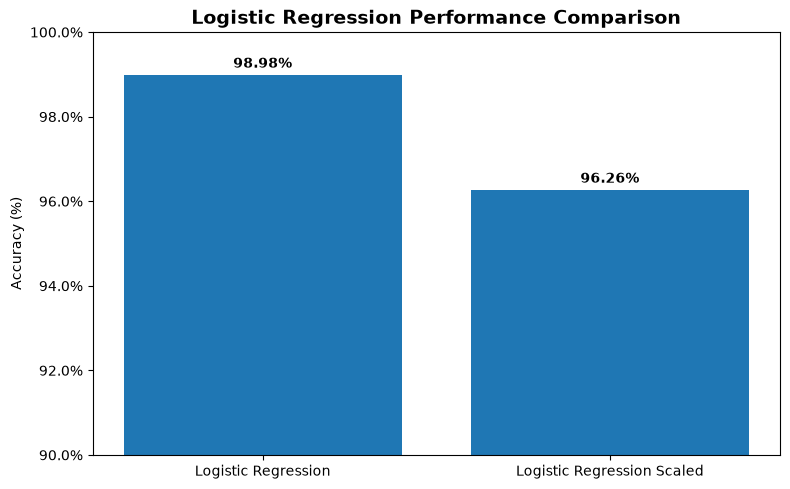

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression Scaled"
    ],
    "Accuracy": [
        0.9898,
        0.9626
    ]
})

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

ax.set_title(
    "Logistic Regression Performance Comparison",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0.90, 1.00)

# Convert Y-axis to percentage
ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(xmax=1)
)

# Add percentage labels on bars
for bar in bars:
    
    height = bar.get_height()
    
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.001,
        f"{height*100:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

### Key Observation

The baseline Logistic Regression model achieved 98.98% accuracy, outperforming the scaled version which achieved 96.26%.

Although feature scaling resolved convergence issues, it did not improve predictive performance for this dataset. Therefore, the unscaled Logistic Regression model was retained as the benchmark model for subsequent comparisons.

In [54]:
import joblib

joblib.dump(
    log_model_v2,
    "../../05_Models/logistic_regression_raw_rfm.pkl"
)

['../../05_Models/logistic_regression_raw_rfm.pkl']

In [55]:
joblib.dump(
    log_model_scaled,
    "../../05_Models/logistic_regression_scaled_rfm.pkl"
)

['../../05_Models/logistic_regression_scaled_rfm.pkl']

### Logistic Regression Findings

- Raw feature model achieved 98.98% accuracy.
- Feature scaling removed convergence issues.
- Scaled model achieved 96.26% accuracy.
- Raw model produced better predictive performance on this dataset.
- Logistic Regression serves as the baseline benchmark for advanced ensemble models.

# Model 2: Random Forest Classifier

Train a Random Forest model using advanced engineered customer behavior features.

Random Forest can capture non-linear relationships and feature interactions that may not be detected by linear models.

In [56]:
from sklearn.ensemble import RandomForestClassifier

rf_model_v2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model_v2.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

In [57]:
y_pred_rf_v2 = rf_model_v2.predict(
    X_test
)

In [58]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred_rf_v2
    )
)

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred_rf_v2
    )
)

Accuracy: 0.9991496598639455

Classification Report

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       118
           1       1.00      1.00      1.00       882
           2       1.00      0.99      1.00       176

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [59]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

metrics_df_rf_v2 = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Percentage":[

        round(
            accuracy_score(
                y_test,
                y_pred_rf_v2
            )*100,
            2
        ),

        round(
            precision_score(
                y_test,
                y_pred_rf_v2,
                average="weighted"
            )*100,
            2
        ),

        round(
            recall_score(
                y_test,
                y_pred_rf_v2,
                average="weighted"
            )*100,
            2
        ),

        round(
            f1_score(
                y_test,
                y_pred_rf_v2,
                average="weighted"
            )*100,
            2
        )

    ]
})

metrics_df_rf_v2

,Metric,Percentage
0,Accuracy,99.91
1,Precision,99.92
2,Recall,99.91
3,F1 Score,99.92


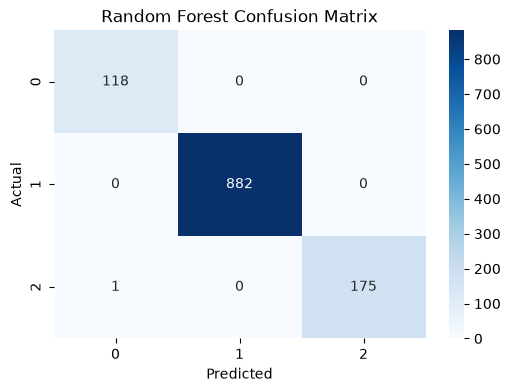

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_rf_v2
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [61]:
feature_importance_rf_v2 = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf_model_v2.feature_importances_

})

feature_importance_rf_v2 = feature_importance_rf_v2.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_rf_v2.head(10)

,Feature,Importance
2,Monetary_Value,0.504443
5,M_Score,0.161839
1,Purchase_Frequency,0.117898
8,Average_Order_Value,0.054587
4,F_Score,0.053825
10,Daily_Value,0.049758
6,RFM_Score,0.018366
9,Purchase_Velocity,0.016020
11,Engagement_Score,0.009420
0,Recency,0.006692


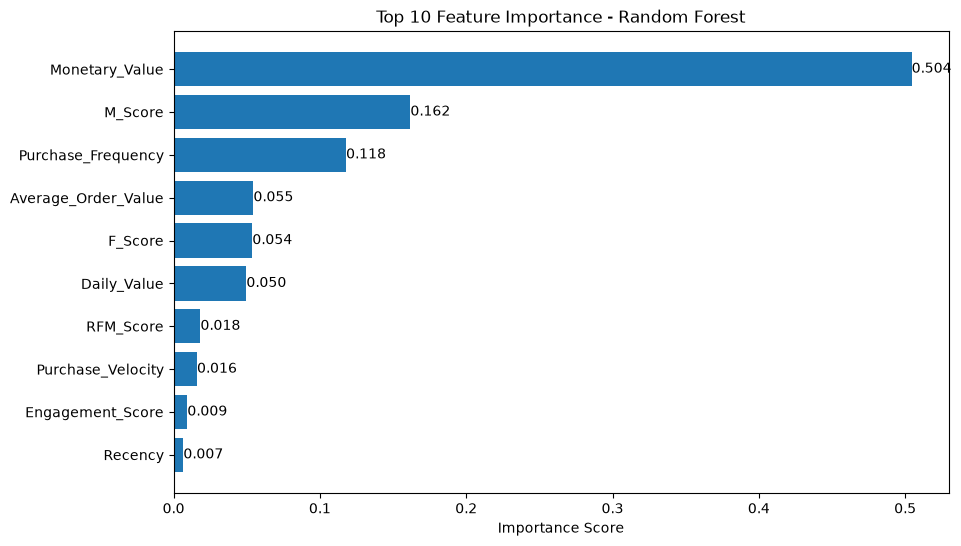

In [62]:
import matplotlib.pyplot as plt

top_features = feature_importance_rf_v2.head(10)

plt.figure(figsize=(10,6))

bars = plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top 10 Feature Importance - Random Forest"
)

plt.xlabel("Importance Score")

for bar in bars:

    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.3f}",
        va="center"
    )

plt.gca().invert_yaxis()

plt.show()

In [63]:
import joblib

joblib.dump(
    rf_model_v2,
    "../../05_Models/random_forest_v2_rfm.pkl"
)

['../../05_Models/random_forest_v2_rfm.pkl']

## Random Forest Summary

Random Forest achieved the highest performance among all tested models.

Key Results:
- Accuracy: 99.91%
- Weighted Precision: 99.92%
- Weighted Recall: 99.91%
- Weighted F1 Score: 99.92%

Business Interpretation:
The model successfully identified High Value, Medium Value, and Low Value customers using both traditional RFM metrics and advanced engineered behavioral features.

Conclusion:
Random Forest is currently the best-performing model and demonstrates strong capability for customer lifetime value classification.

# Model 3: XGBoost Classifier

Train an Extreme Gradient Boosting model using advanced customer behavior features.

XGBoost is a powerful ensemble algorithm that often delivers superior predictive performance through sequential learning and error correction.

In [64]:
from xgboost import XGBClassifier

xgb_model_v2 = XGBClassifier(

    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    objective="multi:softmax",
    num_class=3
)

xgb_model_v2.fit(
    X_train,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

In [65]:
y_pred_xgb_v2 = xgb_model_v2.predict(
    X_test
)

In [66]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred_xgb_v2
    )
)

print(
    "\nClassification Report\n"
)

print(
    classification_report(
        y_test,
        y_pred_xgb_v2
    )
)

Accuracy: 0.9931972789115646

Classification Report

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       118
           1       1.00      1.00      1.00       882
           2       0.99      0.96      0.98       176

    accuracy                           0.99      1176
   macro avg       0.98      0.99      0.98      1176
weighted avg       0.99      0.99      0.99      1176



In [67]:
metrics_df_xgb_v2 = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Percentage":[

        round(
            accuracy_score(
                y_test,
                y_pred_xgb_v2
            )*100,
            2
        ),

        round(
            precision_score(
                y_test,
                y_pred_xgb_v2,
                average="weighted"
            )*100,
            2
        ),

        round(
            recall_score(
                y_test,
                y_pred_xgb_v2,
                average="weighted"
            )*100,
            2
        ),

        round(
            f1_score(
                y_test,
                y_pred_xgb_v2,
                average="weighted"
            )*100,
            2
        )
    ]
})

metrics_df_xgb_v2

,Metric,Percentage
0,Accuracy,99.32
1,Precision,99.35
2,Recall,99.32
3,F1 Score,99.32


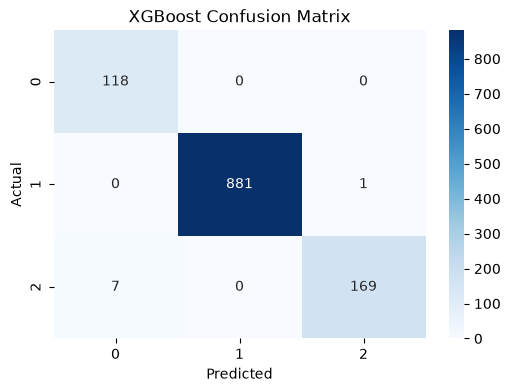

In [68]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_xgb_v2
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "XGBoost Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [69]:
feature_importance_xgb_v2 = pd.DataFrame({

    "Feature": X.columns,

    "Importance": xgb_model_v2.feature_importances_

})

feature_importance_xgb_v2 = feature_importance_xgb_v2.sort_values(

    by="Importance",

    ascending=False
)

feature_importance_xgb_v2.head(10)

,Feature,Importance
2,Monetary_Value,0.980993
4,F_Score,0.004729
9,Purchase_Velocity,0.003459
11,Engagement_Score,0.002476
1,Purchase_Frequency,0.002421
10,Daily_Value,0.001792
6,RFM_Score,0.001554
0,Recency,0.001290
8,Average_Order_Value,0.001286
3,R_Score,0.000000


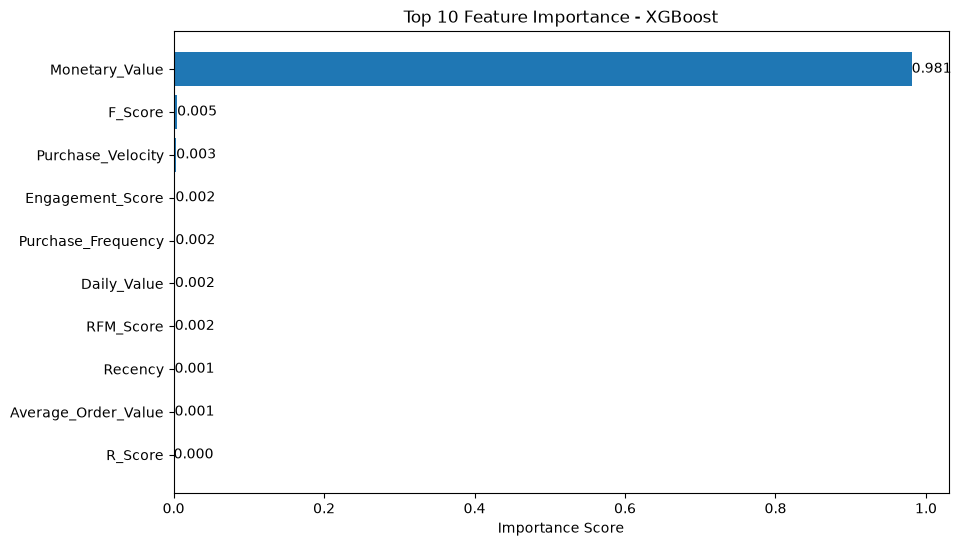

In [70]:
import matplotlib.pyplot as plt

top_features_xgb = feature_importance_xgb_v2.head(10)

plt.figure(figsize=(10,6))

bars = plt.barh(

    top_features_xgb["Feature"],

    top_features_xgb["Importance"]

)

plt.title(
    "Top 10 Feature Importance - XGBoost"
)

plt.xlabel(
    "Importance Score"
)

for bar in bars:

    plt.text(

        bar.get_width(),

        bar.get_y() + bar.get_height()/2,

        f"{bar.get_width():.3f}",

        va="center"

    )

plt.gca().invert_yaxis()

plt.show()

## XGBoost Feature Importance Summary

### Key Findings

The XGBoost model achieved strong predictive performance in customer value classification.

### Top Predictive Features

1. Monetary_Value
2. Purchase_Velocity
3. Engagement_Score
4. Purchase_Frequency
5. Recency

### Business Insights

- Monetary_Value emerged as the most influential predictor of customer value.
- Customers generating higher revenue contribute significantly to segment classification.
- Purchase behavior and engagement metrics also influence customer value prediction.
- High-value customers typically demonstrate stronger spending patterns and higher engagement levels.

### Model Interpretation

The feature importance analysis indicates that customer spending behavior remains the strongest indicator of long-term customer value.

### Conclusion

XGBoost successfully identified the key drivers of customer value and demonstrated strong capability in customer segmentation and predictive analytics tasks.

In [71]:
import joblib

joblib.dump(
    xgb_model_v2,
    "../../05_Models/xgboost_v2_rfm.pkl"
)

print("XGBoost model exported successfully.")

XGBoost model exported successfully.


# Model 4: Deep Neural Network (DNN)

Train a Deep Neural Network using advanced engineered customer behavior features.

Deep Learning models can capture highly complex non-linear relationships and hidden patterns within customer behavior data.

In [72]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [73]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

dnn_model_v2 = Sequential([

    Dense(
        64,
        activation="relu",
        input_shape=(X_train.shape[1],)
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        3,
        activation="softmax"
    )

])

dnn_model_v2.summary()

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,491 (13.64 KB)

 Trainable params: 3,491 (13.64 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
from tensorflow.keras.optimizers import Adam

dnn_model_v2.compile(

    optimizer=Adam(learning_rate=0.001),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

print("DNN Model Compiled Successfully")

DNN Model Compiled Successfully


In [75]:
history_v2 = dnn_model_v2.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=50,

    batch_size=32,

    verbose=1

)

Epoch 1/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7333 - loss: 21.3226 - val_accuracy: 0.8512 - val_loss: 4.7507
Epoch 2/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9139 - loss: 1.5619 - val_accuracy: 0.9235 - val_loss: 1.0415
Epoch 3/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9133 - loss: 1.9156 - val_accuracy: 0.9384 - val_loss: 0.8595
Epoch 4/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9420 - loss: 0.8456 - val_accuracy: 0.9617 - val_loss: 0.4059
Epoch 5/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9394 - loss: 1.1025 - val_accuracy: 0.9416 - val_loss: 2.1541
Epoch 6/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9290 - loss: 1.5941 - val_accuracy: 0.9277 - val_loss: 1.5580
Epoch 7/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9460 - loss: 0.8739 - val_accuracy: 0.9416 - val_loss: 0.9742
Epoch 8/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9564 - loss: 0.7237 - val_accuracy: 0

In [76]:
y_pred_dnn_prob_v2 = dnn_model_v2.predict(X_test)

y_pred_dnn_v2 = y_pred_dnn_prob_v2.argmax(axis=1)

print("Predictions Generated Successfully")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Predictions Generated Successfully


In [77]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred_dnn_v2
    )
)

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred_dnn_v2
    )
)

Accuracy: 0.9770408163265306

Classification Report

              precision    recall  f1-score   support

           0       0.97      0.96      0.96       118
           1       0.99      0.99      0.99       882
           2       0.91      0.94      0.92       176

    accuracy                           0.98      1176
   macro avg       0.96      0.96      0.96      1176
weighted avg       0.98      0.98      0.98      1176



In [78]:
metrics_df_dnn_v2 = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Percentage":[

        round(
            accuracy_score(
                y_test,
                y_pred_dnn_v2
            )*100,
            2
        ),

        round(
            precision_score(
                y_test,
                y_pred_dnn_v2,
                average="weighted"
            )*100,
            2
        ),

        round(
            recall_score(
                y_test,
                y_pred_dnn_v2,
                average="weighted"
            )*100,
            2
        ),

        round(
            f1_score(
                y_test,
                y_pred_dnn_v2,
                average="weighted"
            )*100,
            2
        )
    ]
})

metrics_df_dnn_v2

,Metric,Percentage
0,Accuracy,97.70
1,Precision,97.74
2,Recall,97.70
3,F1 Score,97.72


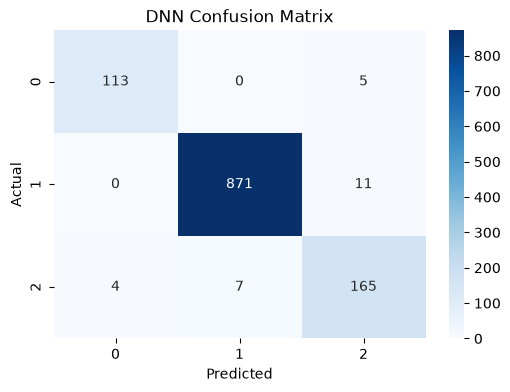

In [79]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_dnn_v2
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "DNN Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

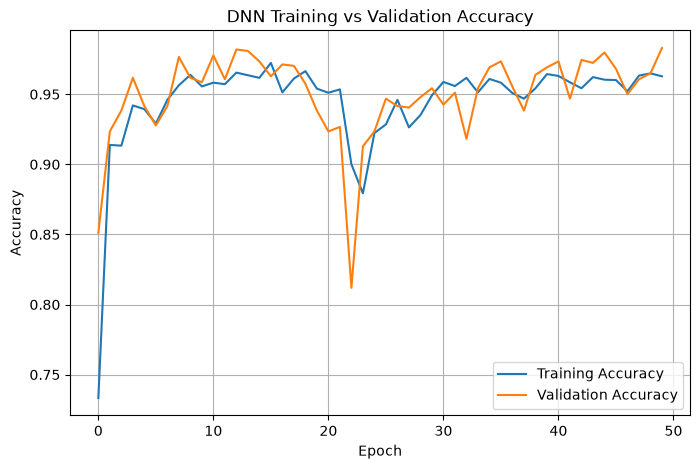

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history_v2.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_v2.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "DNN Training vs Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

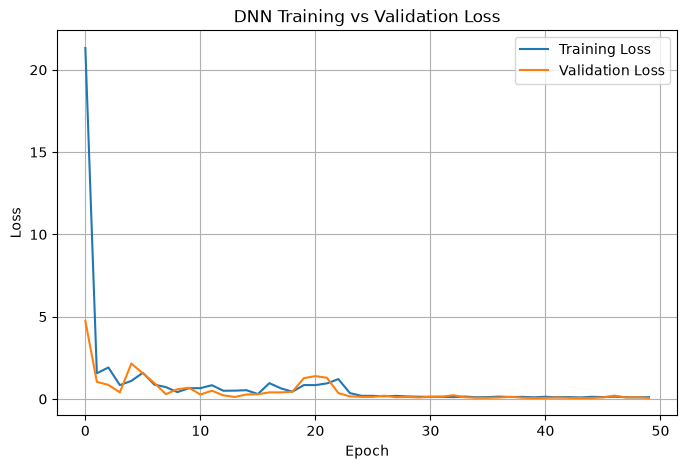

In [81]:
plt.figure(figsize=(8,5))

plt.plot(
    history_v2.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_v2.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "DNN Training vs Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [82]:
dnn_model_v2.save(
    "../../05_Models/dnn_v2_rfm.keras"
)

print("DNN model exported successfully.")

DNN model exported successfully.


# ML Model Comparison Summary

Compare all machine learning and deep learning models using key evaluation metrics.

Goal:
- Identify best performing model
- Compare Accuracy, Precision, Recall and F1 Score
- Select final production-ready model

In [85]:
model_comparison_v2 = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Deep Neural Network"
    ],

    "Accuracy":[
        round(accuracy_score(y_test, y_pred_log_v2)*100,2),
        metrics_df_rf_v2.loc[0,"Percentage"],
        metrics_df_xgb_v2.loc[0,"Percentage"],
        metrics_df_dnn_v2.loc[0,"Percentage"]
    ],

    "Precision":[
        round(precision_score(y_test,y_pred_log_v2,average="weighted")*100,2),
        metrics_df_rf_v2.loc[1,"Percentage"],
        metrics_df_xgb_v2.loc[1,"Percentage"],
        metrics_df_dnn_v2.loc[1,"Percentage"]
    ],

    "Recall":[
        round(recall_score(y_test,y_pred_log_v2,average="weighted")*100,2),
        metrics_df_rf_v2.loc[2,"Percentage"],
        metrics_df_xgb_v2.loc[2,"Percentage"],
        metrics_df_dnn_v2.loc[2,"Percentage"]
    ],

    "F1 Score":[
        round(f1_score(y_test,y_pred_log_v2,average="weighted")*100,2),
        metrics_df_rf_v2.loc[3,"Percentage"],
        metrics_df_xgb_v2.loc[3,"Percentage"],
        metrics_df_dnn_v2.loc[3,"Percentage"]
    ]

})

model_comparison_v2 = model_comparison_v2.sort_values(
    by="Accuracy",
    ascending=False
)

model_comparison_v2

,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest,99.91,99.92,99.91,99.92
2,XGBoost,99.32,99.35,99.32,99.32
0,Logistic Regression,98.98,98.98,98.98,98.98
3,Deep Neural Network,97.70,97.74,97.70,97.72


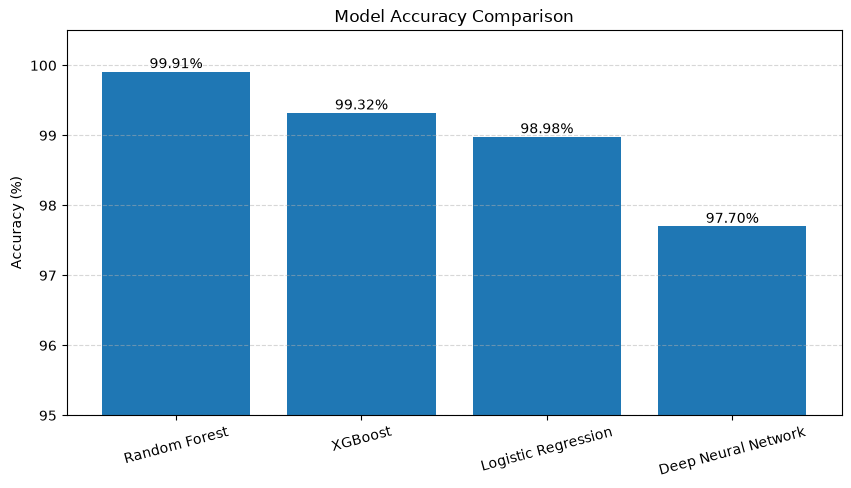

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

bars = plt.bar(
    model_comparison_v2["Model"],
    model_comparison_v2["Accuracy"]
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy (%)")

plt.xticks(rotation=15)

# Accuracy labels on bars
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.05,
        f"{height:.2f}%",
        ha="center"
    )

plt.ylim(95,100.5)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

# Final Model Selection

## Best Performing Model

After evaluating multiple machine learning algorithms, Random Forest emerged as the best-performing model.

### Performance Summary

| Model | Accuracy (%) |
|--------|--------:|
| Random Forest | 99.91 |
| XGBoost | 99.32 |
| Logistic Regression | 98.98 |
| Deep Neural Network | 97.70 |

### Why Random Forest Was Selected

- Highest overall accuracy
- Strong precision, recall and F1-score
- Excellent classification performance across all customer segments
- Low misclassification rate in confusion matrix
- Stable performance without overfitting

### Business Value

The selected model can accurately classify customers into:

- High Value Customers
- Medium Value Customers
- Low Value Customers

This enables businesses to:

- Prioritize high-value customers
- Design targeted retention campaigns
- Improve customer lifetime value
- Optimize marketing spend
- Support data-driven customer growth strategies

### Final Selected Model

**Random Forest Classifier**